# Classificacao de Sentimento com IMDB

Notebook revisado para treinar e comparar modelos de classificacao de reviews com meta de `F1 >= 0.85` no conjunto de teste.


## 1. Inicializacao

O fluxo principal usa modelos classicos de texto. BERT fica como etapa opcional no final.


In [22]:
from pathlib import Path
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, precision_recall_curve, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
tqdm.pandas()


In [23]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style='whitegrid')


## 2. Carregamento dos dados


In [24]:
candidate_paths = [
    Path('../Data/imdb_reviews.tsv'),
    Path('..') / 'Data' / 'imdb_reviews.tsv',
    Path.cwd() / 'Bert' / 'Data' / 'imdb_reviews.tsv',
    Path.cwd() / 'Data' / 'imdb_reviews.tsv',
]

data_path = next((path.resolve() for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Nao encontrei imdb_reviews.tsv. Ajuste candidate_paths para o seu ambiente.')

df_reviews = pd.read_csv(data_path, sep='\t', dtype={'votes': 'Int64'})
print(f'Arquivo carregado: {data_path}')
print(df_reviews.shape)


Arquivo carregado: C:\TT\Bert\Bert\Data\imdb_reviews.tsv
(47331, 17)


In [25]:
display(df_reviews.head())
df_reviews.info()


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [26]:
required_columns = ['review', 'pos', 'ds_part']
missing_columns = [column for column in required_columns if column not in df_reviews.columns]
if missing_columns:
    raise ValueError(f'Colunas obrigatorias ausentes: {missing_columns}')

display(df_reviews[required_columns].isna().sum().to_frame('missing_values'))
display(df_reviews['ds_part'].value_counts().to_frame('rows'))
display(pd.crosstab(df_reviews['ds_part'], df_reviews['pos'], normalize='index').round(3))


,missing_values
review,0
pos,0
ds_part,0


,rows
ds_part,
train,23796
test,23535


pos,0,1
ds_part,,
test,0.502,0.498
train,0.501,0.499


## 3. AED


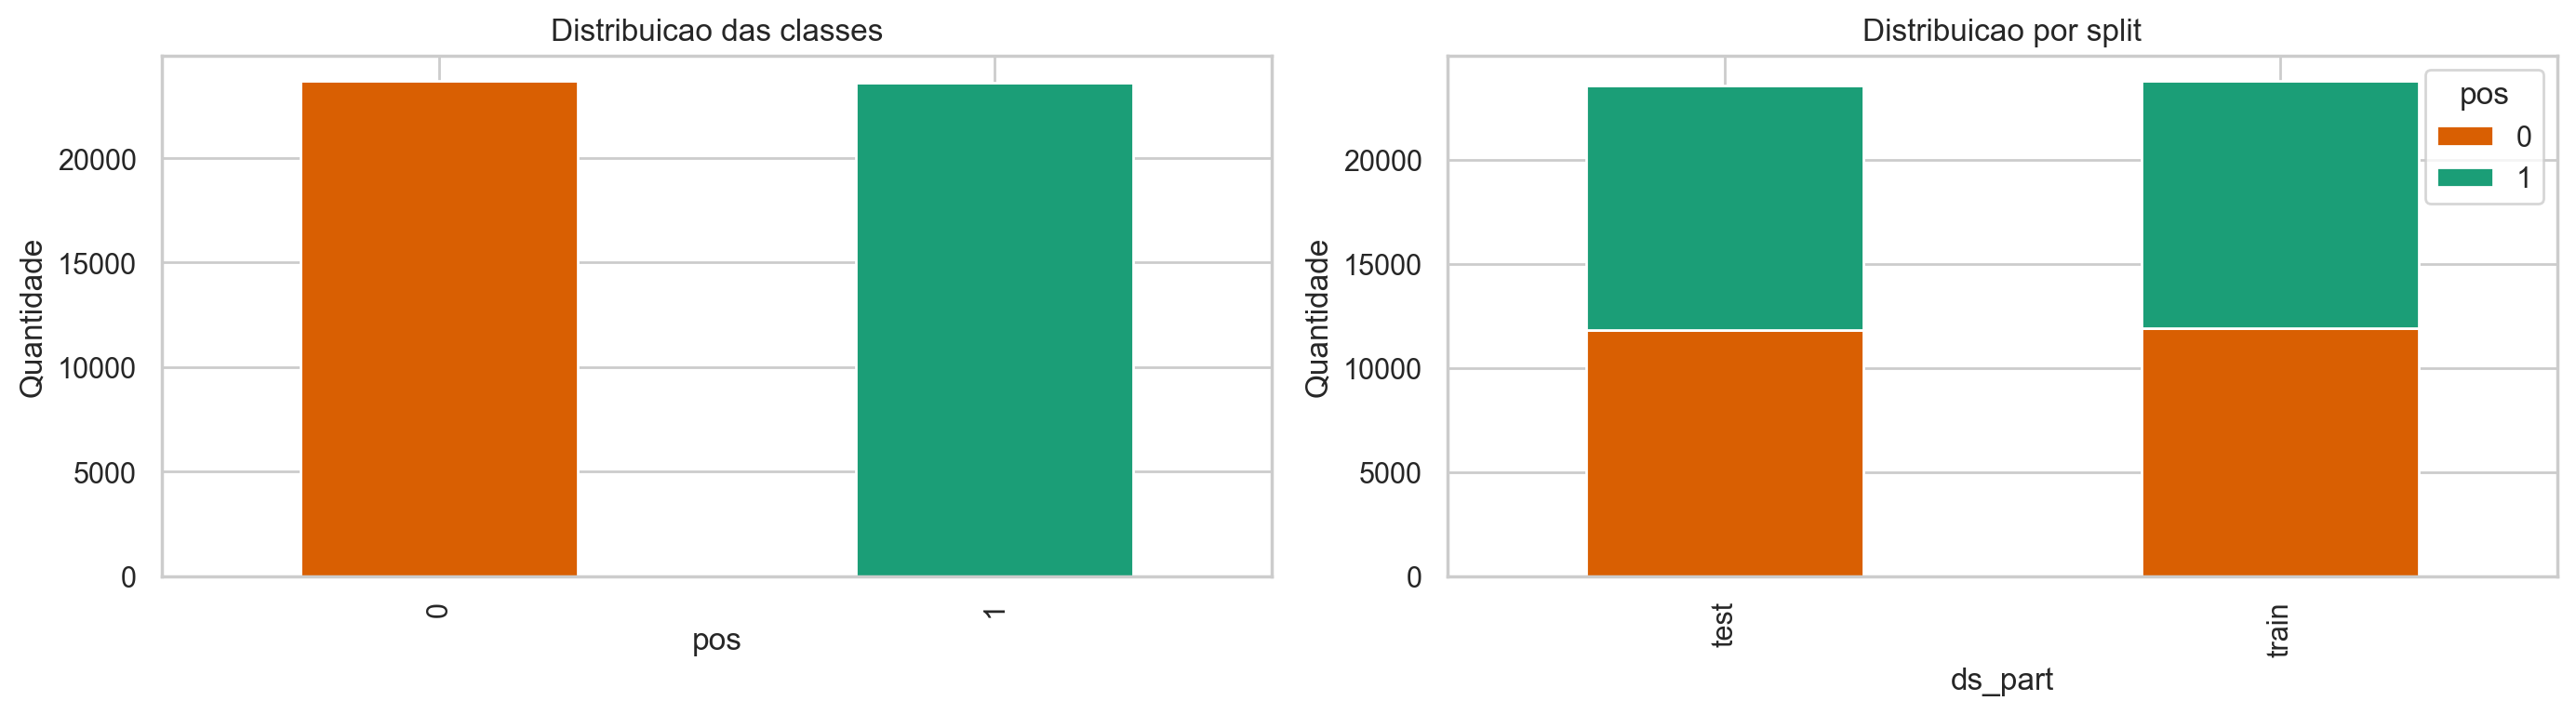

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

df_reviews['pos'].value_counts().sort_index().plot(kind='bar', ax=axs[0], color=['#d95f02', '#1b9e77'])
axs[0].set_title('Distribuicao das classes')
axs[0].set_xlabel('pos')
axs[0].set_ylabel('Quantidade')

pd.crosstab(df_reviews['ds_part'], df_reviews['pos']).plot(kind='bar', stacked=True, ax=axs[1], color=['#d95f02', '#1b9e77'])
axs[1].set_title('Distribuicao por split')
axs[1].set_xlabel('ds_part')
axs[1].set_ylabel('Quantidade')

plt.tight_layout()


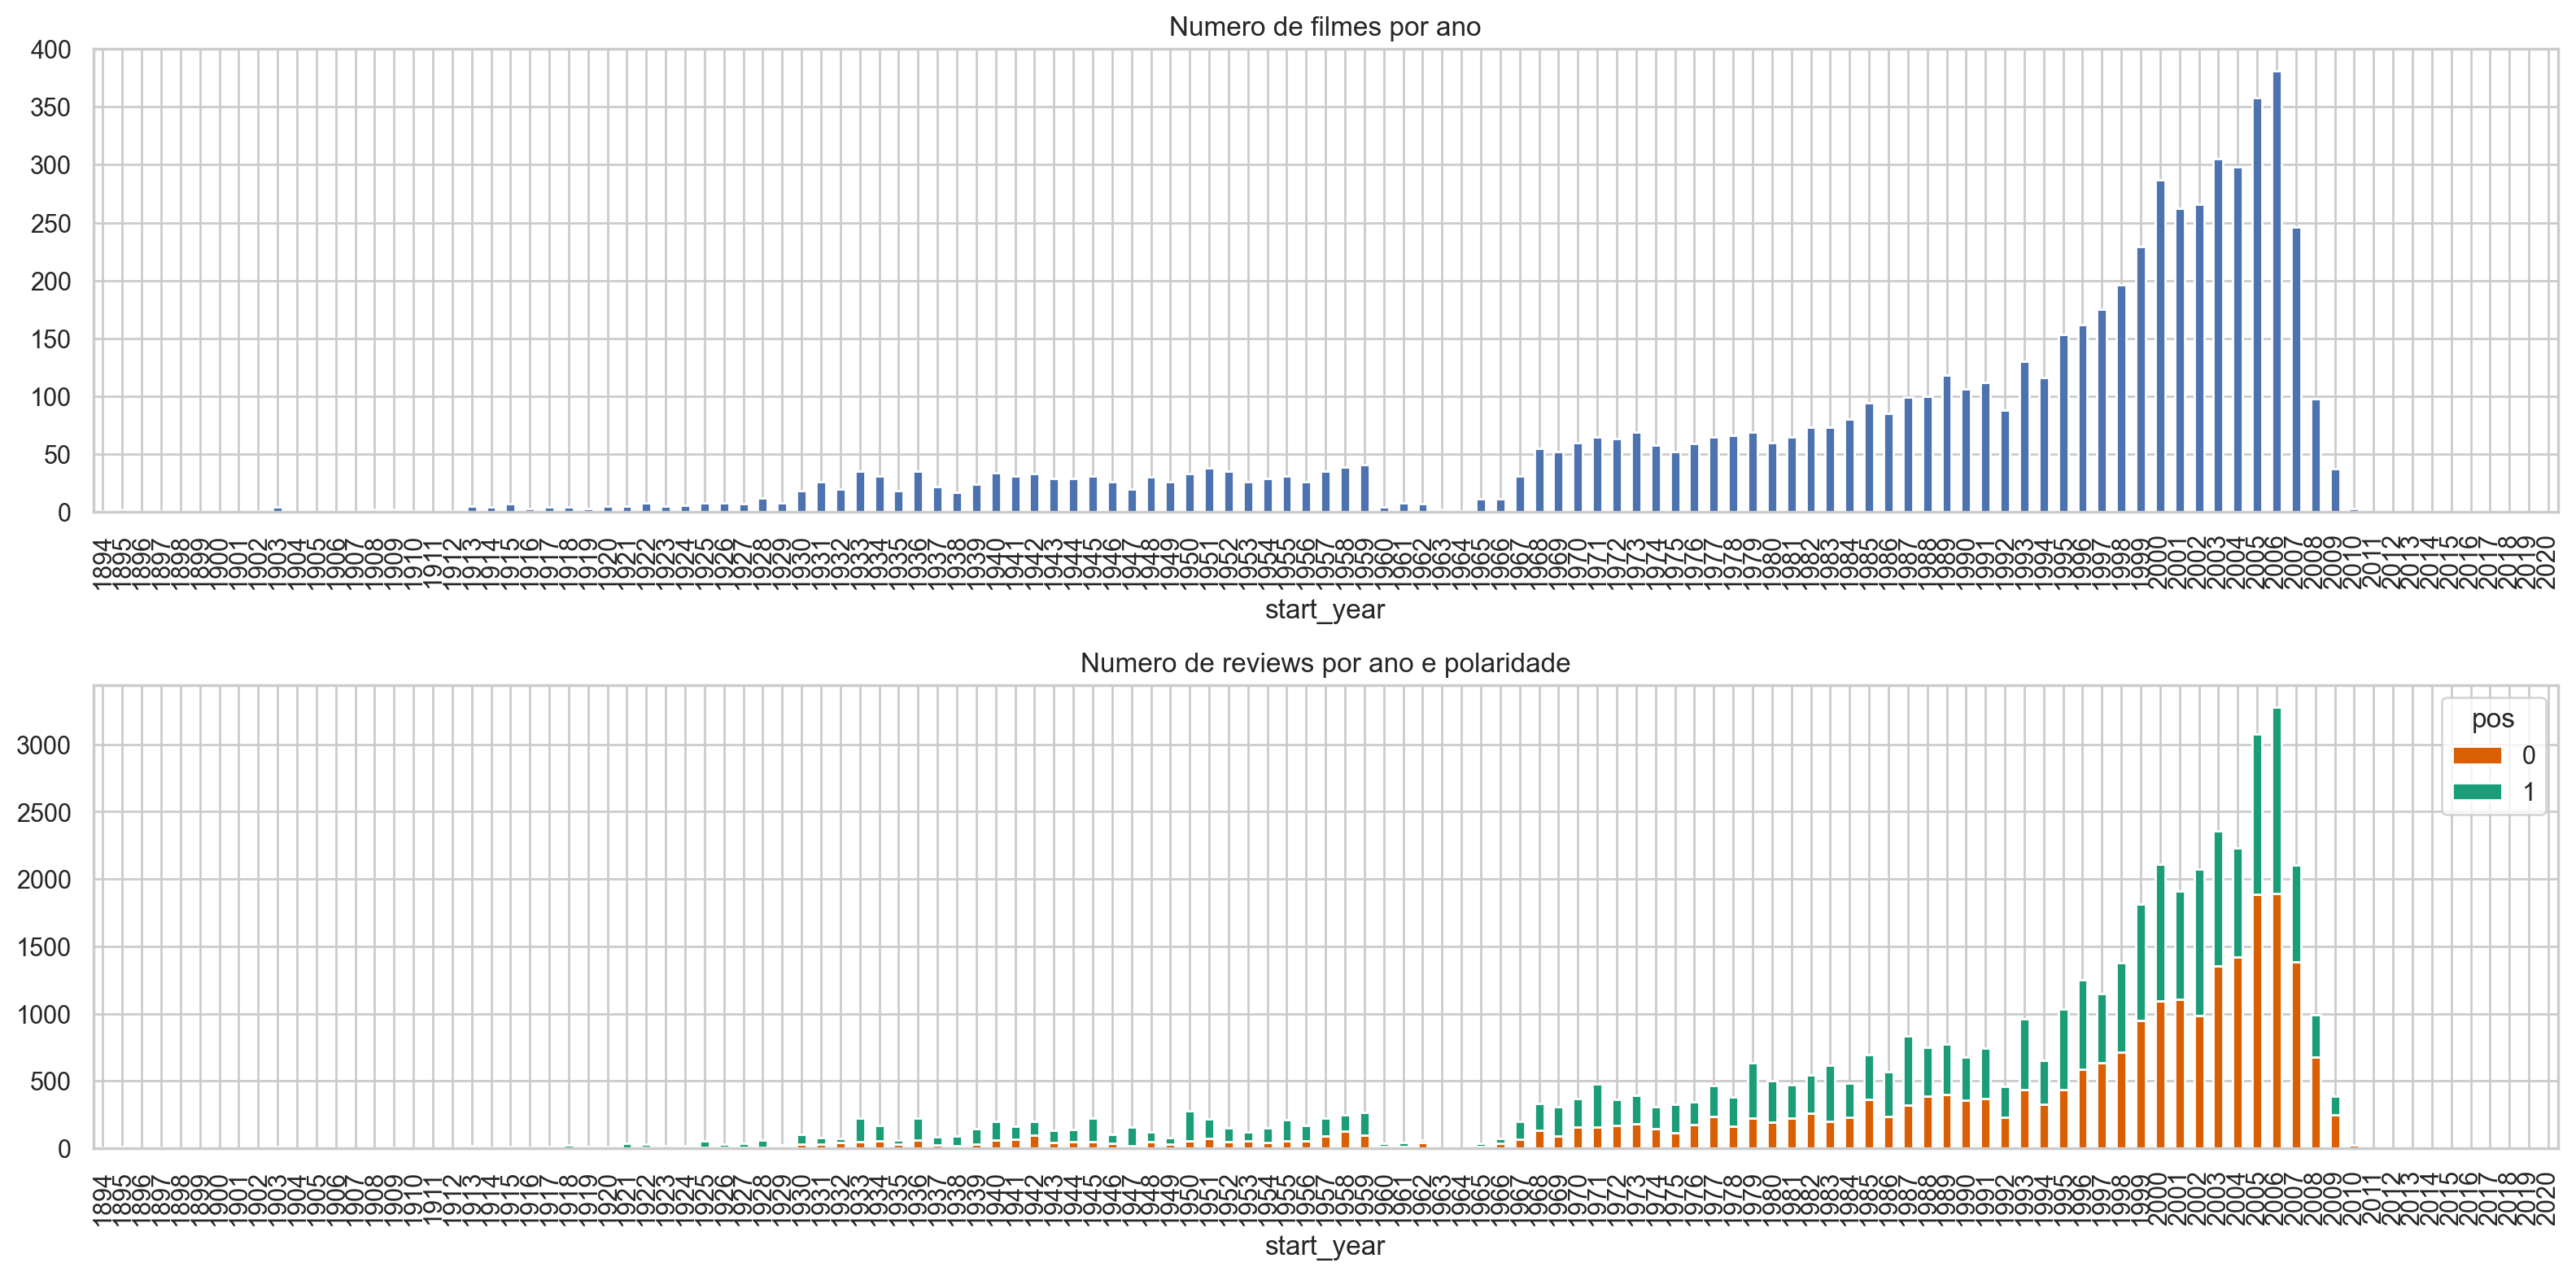

In [28]:
if {'start_year', 'tconst'}.issubset(df_reviews.columns):
    fig, axs = plt.subplots(2, 1, figsize=(16, 8))

    dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates()['start_year'].value_counts().sort_index()
    dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
    dft1.plot(kind='bar', ax=axs[0])
    axs[0].set_title('Numero de filmes por ano')

    dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack().fillna(0)
    dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
    dft2.plot(kind='bar', stacked=True, ax=axs[1], color=['#d95f02', '#1b9e77'])
    axs[1].set_title('Numero de reviews por ano e polaridade')

    plt.tight_layout()
else:
    print('Colunas start_year e tconst nao disponiveis. Pulando graficos temporais.')


Conclusao inicial: observe se as classes estao aproximadamente balanceadas e se treino e teste tem proporcoes parecidas. Se estiverem, nao ha sinal imediato de necessidade de rebalanceamento.


## 4. Normalizacao de texto


In [29]:
def normalize_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r"[^a-z']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_reviews['review_norm'] = df_reviews['review'].progress_apply(normalize_text)
display(df_reviews[['review', 'review_norm']].head())
print('Reviews vazias apos normalizacao:', (df_reviews['review_norm'].str.len() == 0).sum())


  0%|          | 0/47331 [00:00<?, ?it/s]

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i'm totally agree with garryjohal from singapo...


Reviews vazias apos normalizacao: 0


## 5. Split de treino e teste


In [30]:
df_reviews_train = df_reviews.query("ds_part == 'train'").copy()
df_reviews_test = df_reviews.query("ds_part == 'test'").copy()

train_texts = df_reviews_train['review_norm']
test_texts = df_reviews_test['review_norm']
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print('Train:', df_reviews_train.shape)
print('Test :', df_reviews_test.shape)


Train: (23796, 18)
Test : (23535, 18)


## 6. Funcao de avaliacao


In [31]:
def evaluate_model(model, train_features, train_target, test_features, test_target, model_name='model'):
    eval_stats = {}
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    for split_name, features, target, color in [
        ('train', train_features, train_target, '#1f77b4'),
        ('test', test_features, test_target, '#2ca02c'),
    ]:
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        f1_at_05 = f1_score(target, pred_target)
        thresholds = np.arange(0.0, 1.01, 0.05)
        f1_scores = [f1_score(target, pred_proba >= threshold) for threshold in thresholds]

        fpr, tpr, roc_thresholds = roc_curve(target, pred_proba)
        precision, recall, pr_thresholds = precision_recall_curve(target, pred_proba)

        eval_stats[split_name] = {
            'Accuracy': accuracy_score(target, pred_target),
            'F1': f1_at_05,
            'APS': average_precision_score(target, pred_proba),
            'ROC AUC': roc_auc_score(target, pred_proba),
        }

        best_idx = int(np.argmax(f1_scores))
        axs[0].plot(thresholds, f1_scores, color=color, label=f"{split_name}: max={f1_scores[best_idx]:.3f} @ {thresholds[best_idx]:.2f}")
        axs[1].plot(fpr, tpr, color=color, label=f"{split_name}: AUC={eval_stats[split_name]['ROC AUC']:.3f}")
        axs[2].plot(recall, precision, color=color, label=f"{split_name}: AP={eval_stats[split_name]['APS']:.3f}")

    axs[0].set_title(f'F1 por threshold - {model_name}')
    axs[0].set_xlabel('threshold')
    axs[0].set_ylabel('F1')
    axs[0].legend()

    axs[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axs[1].set_title(f'Curva ROC - {model_name}')
    axs[1].set_xlabel('FPR')
    axs[1].set_ylabel('TPR')
    axs[1].legend()

    axs[2].set_title(f'Precision-Recall - {model_name}')
    axs[2].set_xlabel('Recall')
    axs[2].set_ylabel('Precision')
    axs[2].legend()
    plt.tight_layout()

    df_eval_stats = pd.DataFrame(eval_stats).round(3)
    display(df_eval_stats)
    return df_eval_stats


## 7. Modelo baseline


,train,test
Accuracy,0.501,0.502
F1,0.000,0.000
APS,0.499,0.498
ROC AUC,0.500,0.500


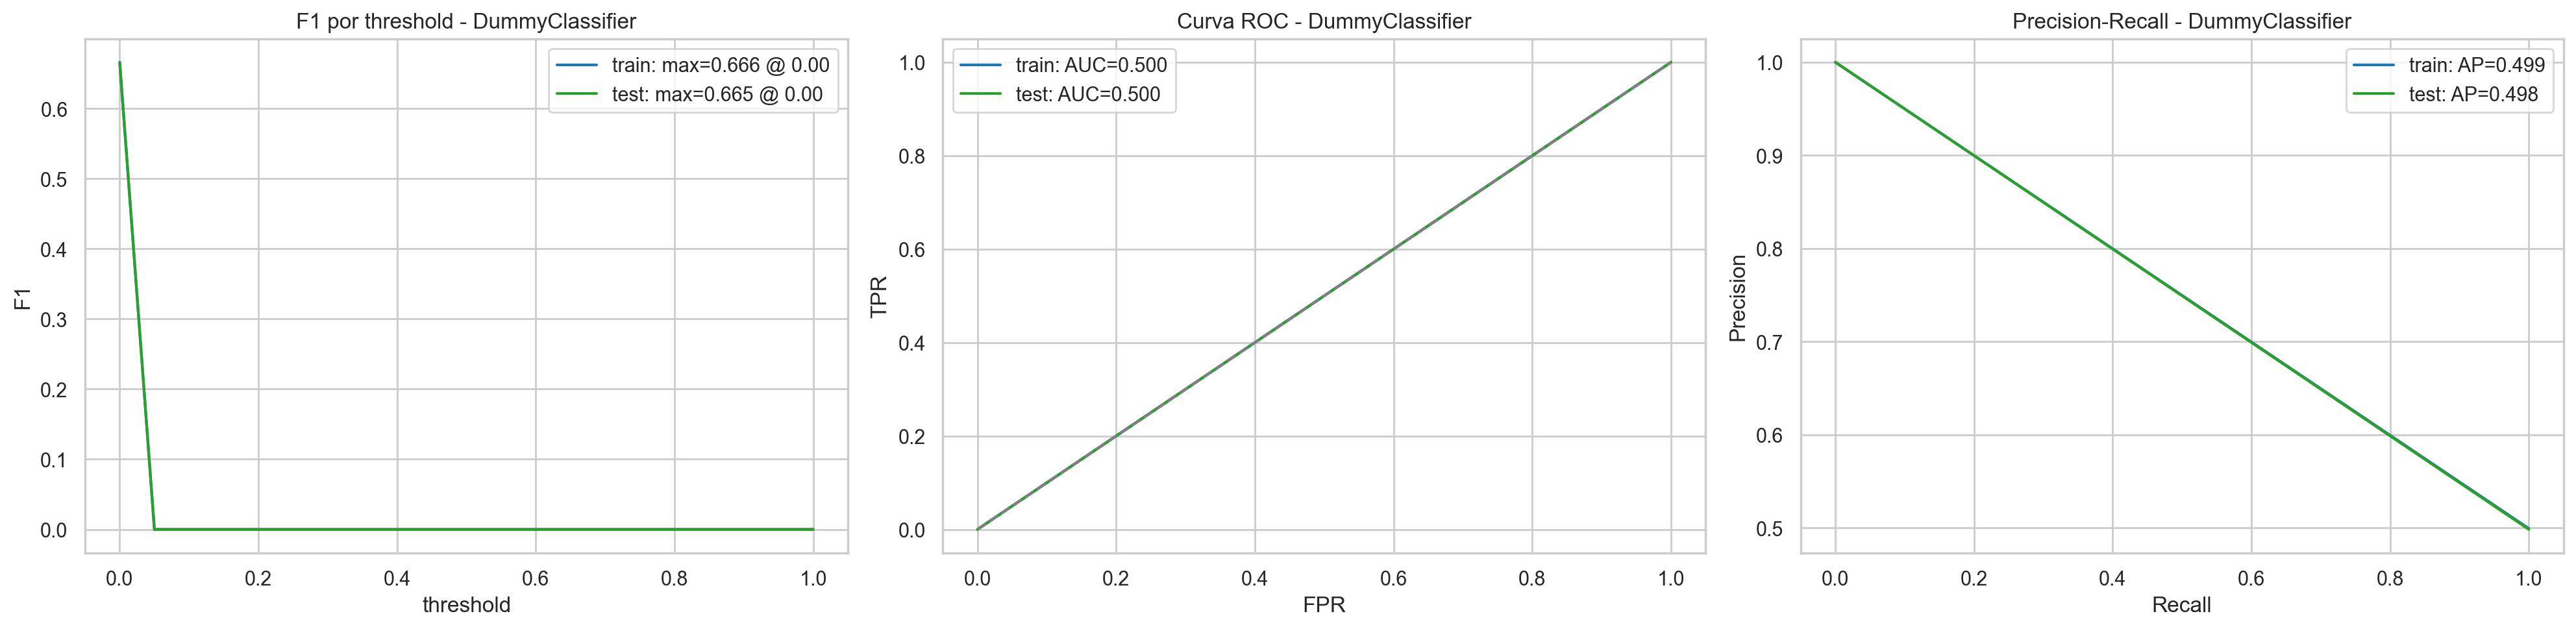

In [32]:
model_dummy = DummyClassifier(strategy='most_frequent')

train_features_dummy = np.zeros((len(train_target), 1))
test_features_dummy = np.zeros((len(test_target), 1))

model_dummy.fit(train_features_dummy, train_target)
results_dummy = evaluate_model(
    model_dummy,
    train_features_dummy,
    train_target,
    test_features_dummy,
    test_target,
    model_name='DummyClassifier'
)


## 8. Modelo principal: TF-IDF + LogisticRegression


,train,test
Accuracy,0.947,0.881
F1,0.948,0.881
APS,0.988,0.949
ROC AUC,0.988,0.951


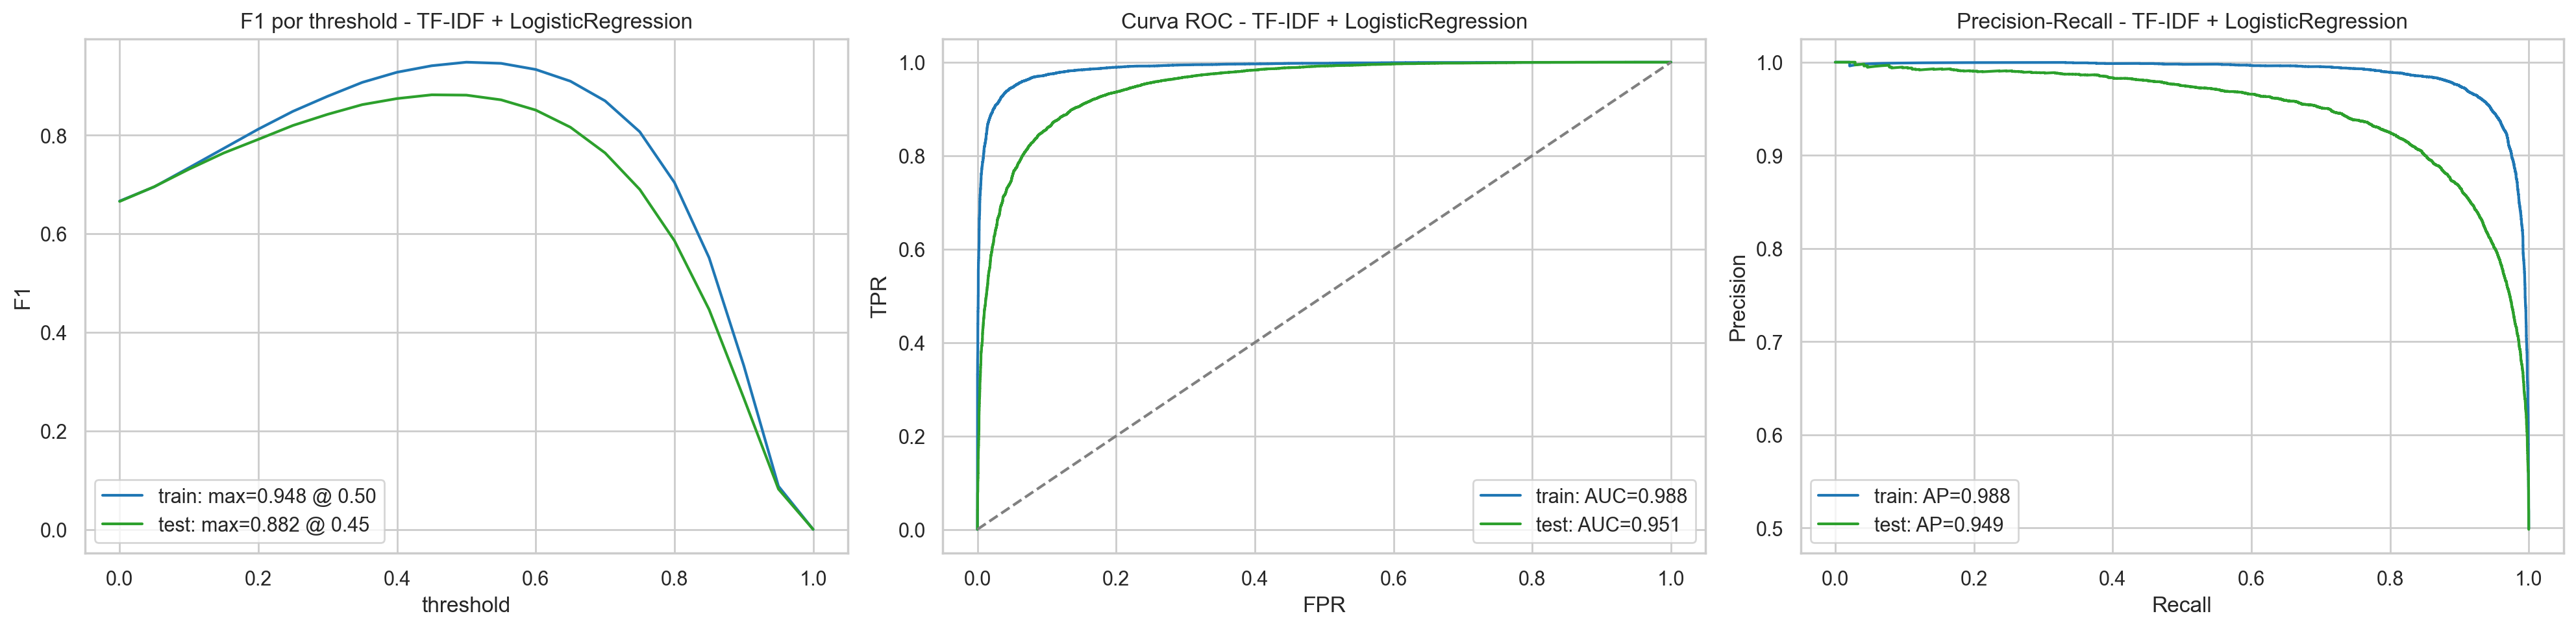

In [33]:
tfidf_vectorizer_lr = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=4,
    max_df=0.9,
)

train_features_lr = tfidf_vectorizer_lr.fit_transform(train_texts)
test_features_lr = tfidf_vectorizer_lr.transform(test_texts)

model_lr_tfidf = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model_lr_tfidf.fit(train_features_lr, train_target)

results_lr = evaluate_model(
    model_lr_tfidf,
    train_features_lr,
    train_target,
    test_features_lr,
    test_target,
    model_name='TF-IDF + LogisticRegression'
)


## 9. Modelos opcionais com spaCy e LightGBM

Esses blocos sao executados apenas se os pacotes estiverem disponiveis no ambiente.


In [34]:
HAS_SPACY = False
HAS_LGBM = False

try:
    import spacy
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    HAS_SPACY = True
    print('spaCy carregado com sucesso.')
except Exception as exc:
    print(f'spaCy indisponivel: {exc}')

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
    print('LightGBM carregado com sucesso.')
except Exception as exc:
    print(f'LightGBM indisponivel: {exc}')


spaCy carregado com sucesso.
LightGBM carregado com sucesso.


  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

,train,test
Accuracy,0.942,0.876
F1,0.943,0.876
APS,0.986,0.945
ROC AUC,0.986,0.948


[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.865462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 556152
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 16484
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353


,train,test
Accuracy,0.935,0.864
F1,0.936,0.864
APS,0.985,0.938
ROC AUC,0.985,0.940


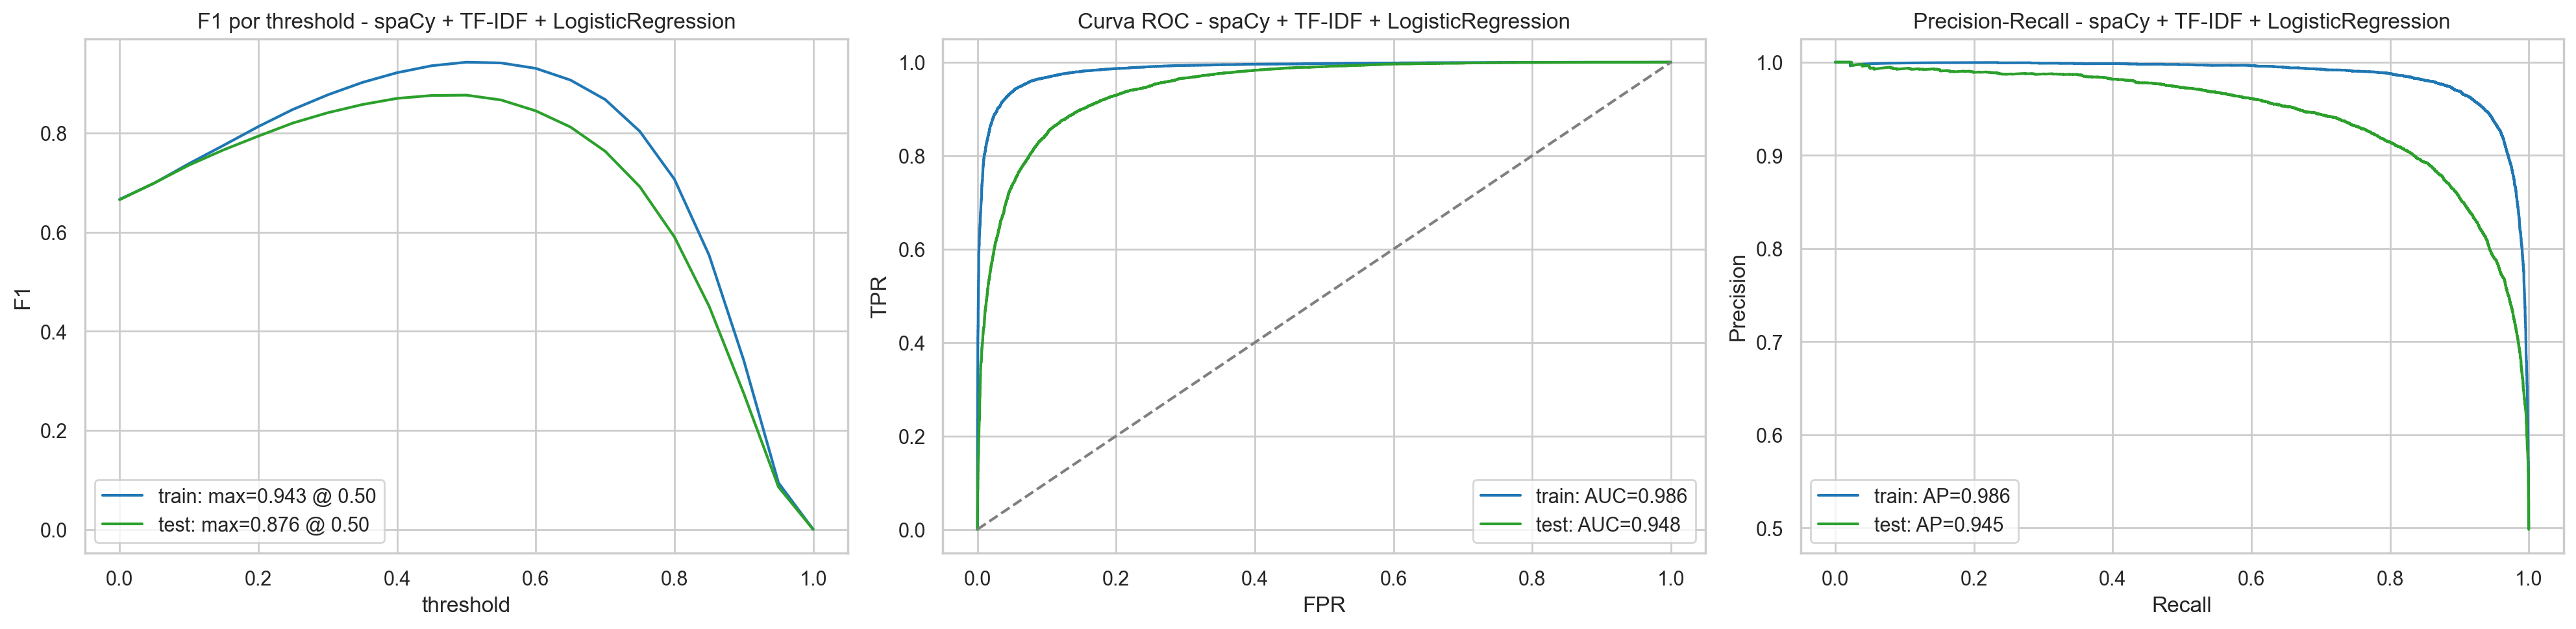

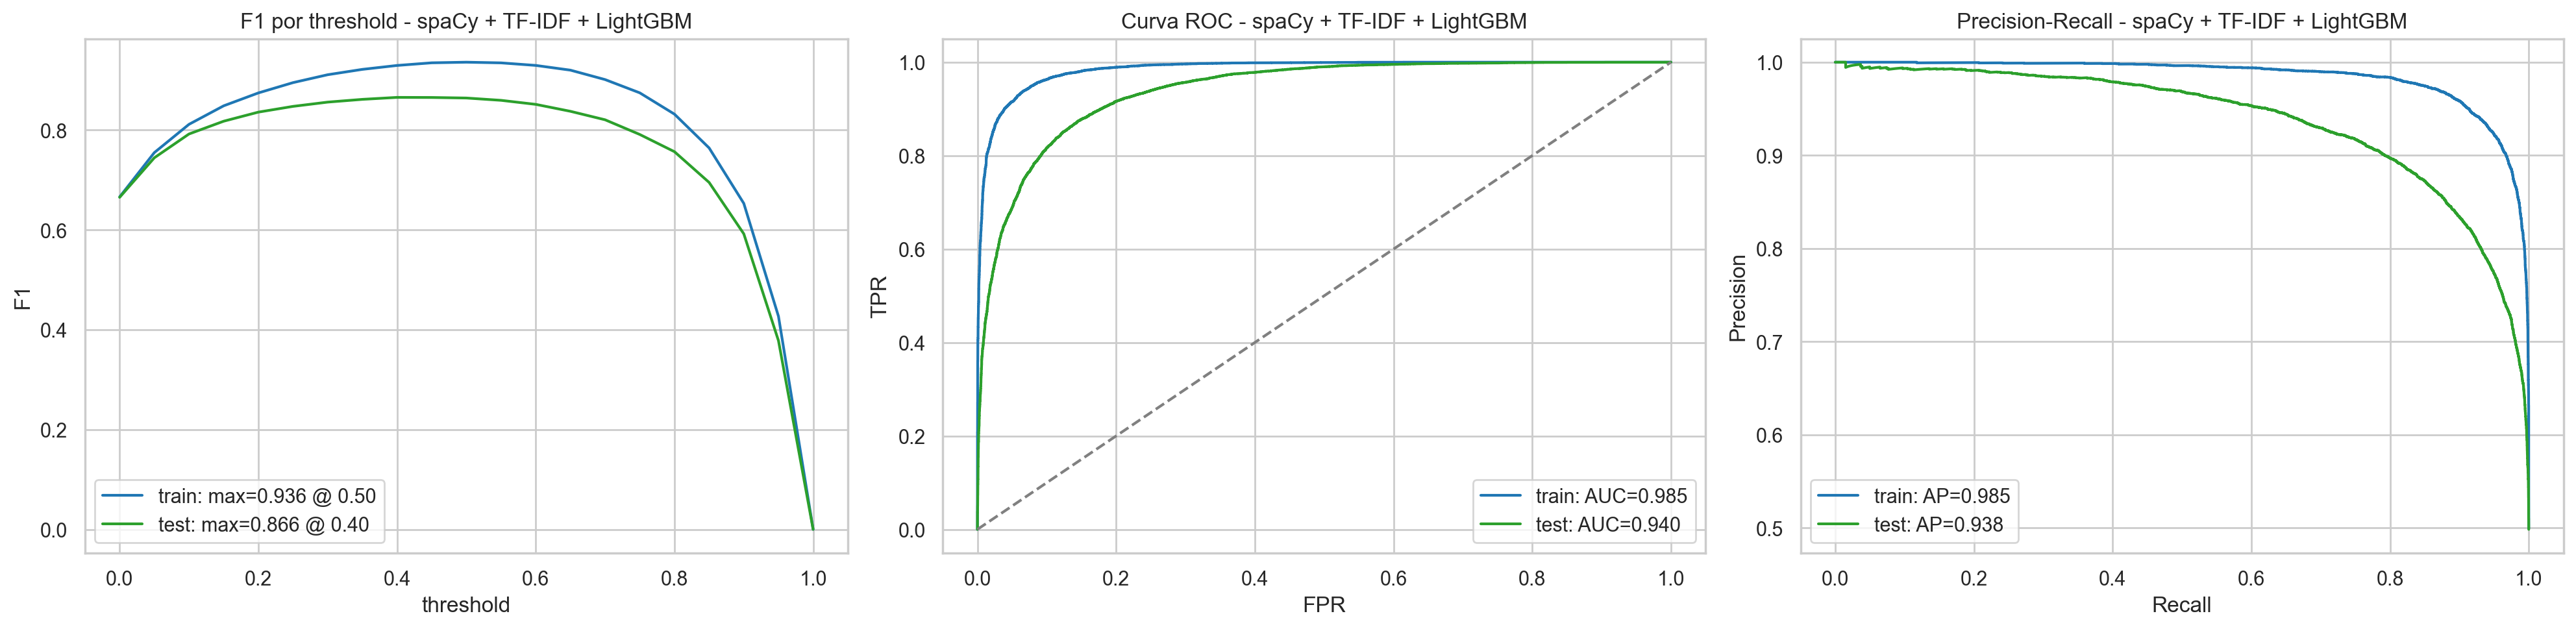

In [35]:
def text_preprocessing_spacy(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_space]
    return ' '.join(tokens)

results_spacy_lr = None
results_spacy_lgbm = None

if HAS_SPACY:
    train_texts_spacy = train_texts.progress_apply(text_preprocessing_spacy)
    test_texts_spacy = test_texts.progress_apply(text_preprocessing_spacy)

    tfidf_vectorizer_spacy = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        min_df=4,
        max_df=0.9,
    )
    train_features_spacy = tfidf_vectorizer_spacy.fit_transform(train_texts_spacy)
    test_features_spacy = tfidf_vectorizer_spacy.transform(test_texts_spacy)

    model_spacy_lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
    model_spacy_lr.fit(train_features_spacy, train_target)
    results_spacy_lr = evaluate_model(
        model_spacy_lr,
        train_features_spacy,
        train_target,
        test_features_spacy,
        test_target,
        model_name='spaCy + TF-IDF + LogisticRegression'
    )

    if HAS_LGBM:
        model_spacy_lgbm = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
        )
        model_spacy_lgbm.fit(train_features_spacy, train_target)
        results_spacy_lgbm = evaluate_model(
            model_spacy_lgbm,
            train_features_spacy,
            train_target,
            test_features_spacy,
            test_target,
            model_name='spaCy + TF-IDF + LightGBM'
        )
else:
    print('Pulando modelos opcionais porque spaCy nao esta disponivel.')


## 10. Comparacao consolidada


In [36]:
comparison_rows = {
    'dummy': results_dummy['test'],
    'tfidf_lr': results_lr['test'],
}

if results_spacy_lr is not None:
    comparison_rows['spacy_lr'] = results_spacy_lr['test']
if results_spacy_lgbm is not None:
    comparison_rows['spacy_lgbm'] = results_spacy_lgbm['test']

comparison_df = pd.DataFrame(comparison_rows).T.sort_values('F1', ascending=False)
display(comparison_df.round(3))


,Accuracy,F1,APS,ROC AUC
tfidf_lr,0.881,0.881,0.949,0.951
spacy_lr,0.876,0.876,0.945,0.948
spacy_lgbm,0.864,0.864,0.938,0.940
dummy,0.502,0.000,0.498,0.500


## 11. Reviews proprias

Como o dataset e os modelos estao em ingles, o ideal e testar reviews manuais tambem em ingles.


In [37]:
my_reviews = pd.DataFrame([
    'I did not enjoy this movie at all. It was boring and too long.',
    'The plot was weak, but the acting was still decent.',
    'I was completely absorbed by the film and would watch it again.',
    'What a mess. Bad dialogue, weak characters and a frustrating ending.',
    'A surprisingly warm and clever remake that respects the original.',
    'Not perfect, but overall a solid and enjoyable movie.',
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)
display(my_reviews)


,review,review_norm
0,I did not enjoy this movie at all. It was bori...,i did not enjoy this movie at all it was borin...
1,"The plot was weak, but the acting was still de...",the plot was weak but the acting was still decent
2,I was completely absorbed by the film and woul...,i was completely absorbed by the film and woul...
3,"What a mess. Bad dialogue, weak characters and...",what a mess bad dialogue weak characters and a...
4,A surprisingly warm and clever remake that res...,a surprisingly warm and clever remake that res...
5,"Not perfect, but overall a solid and enjoyable...",not perfect but overall a solid and enjoyable ...


In [38]:
texts = my_reviews['review_norm']
my_reviews_pred_prob = model_lr_tfidf.predict_proba(tfidf_vectorizer_lr.transform(texts))[:, 1]

for review, probability in zip(my_reviews['review'], my_reviews_pred_prob):
    print(f'{probability:.3f} -> {review}')


0.176 -> I did not enjoy this movie at all. It was boring and too long.
0.082 -> The plot was weak, but the acting was still decent.
0.493 -> I was completely absorbed by the film and would watch it again.
0.035 -> What a mess. Bad dialogue, weak characters and a frustrating ending.
0.592 -> A surprisingly warm and clever remake that respects the original.
0.966 -> Not perfect, but overall a solid and enjoyable movie.


In [39]:
if HAS_SPACY:
    texts_spacy = texts.apply(text_preprocessing_spacy)
    my_reviews_pred_prob_spacy = model_spacy_lr.predict_proba(tfidf_vectorizer_spacy.transform(texts_spacy))[:, 1]
    for review, probability in zip(my_reviews['review'], my_reviews_pred_prob_spacy):
        print(f'{probability:.3f} -> {review}')
else:
    print('spaCy nao disponivel. Pulando inferencia manual do modelo spaCy.')


0.380 -> I did not enjoy this movie at all. It was boring and too long.
0.105 -> The plot was weak, but the acting was still decent.
0.434 -> I was completely absorbed by the film and would watch it again.
0.029 -> What a mess. Bad dialogue, weak characters and a frustrating ending.
0.586 -> A surprisingly warm and clever remake that respects the original.
0.966 -> Not perfect, but overall a solid and enjoyable movie.


## 12. BERT opcional

Use esta etapa apenas depois de validar os modelos classicos. Em CPU ela pode ser lenta.


In [40]:
HAS_BERT = False

try:
    import torch
    import transformers
    bert_tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
    bert_model = transformers.BertModel.from_pretrained('bert-base-uncased')
    HAS_BERT = True
    print('BERT carregado com sucesso.')
except Exception as exc:
    print(f'BERT indisponivel: {exc}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT carregado com sucesso.


In [47]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=32, force_device=None, disable_progress_bar=False):
    if not HAS_BERT:
        raise RuntimeError('BERT nao esta disponivel neste ambiente.')

    encoded = bert_tokenizer(
        list(texts),
        add_special_tokens=True,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_attention_mask=True,
        return_tensors='np',
    )

    ids_list = encoded['input_ids']
    attention_mask_list = encoded['attention_mask']

    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    bert_model.to(device)
    bert_model.eval()
    if not disable_progress_bar:
        print(f'Usando dispositivo: {device}')

    embeddings = []
    total_batches = math.ceil(len(ids_list) / batch_size)

    for i in tqdm(range(total_batches), disable=disable_progress_bar):
        start = i * batch_size
        end = (i + 1) * batch_size

        ids_batch = torch.LongTensor(ids_list[start:end]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[start:end]).to(device)

        with torch.no_grad():
            batch_embeddings = bert_model(input_ids=ids_batch, attention_mask=attention_mask_batch)
        embeddings.append(batch_embeddings.last_hidden_state[:, 0, :].detach().cpu().numpy())

    return np.concatenate(embeddings)


Usando dispositivo: cpu


  0%|          | 0/63 [00:00<?, ?it/s]

Usando dispositivo: cpu


  0%|          | 0/63 [00:00<?, ?it/s]

,train,test
Accuracy,0.939,0.827
F1,0.940,0.823
APS,0.988,0.903
ROC AUC,0.987,0.909


,train,test
Accuracy,0.939,0.827
F1,0.940,0.823
APS,0.988,0.903
ROC AUC,0.987,0.909


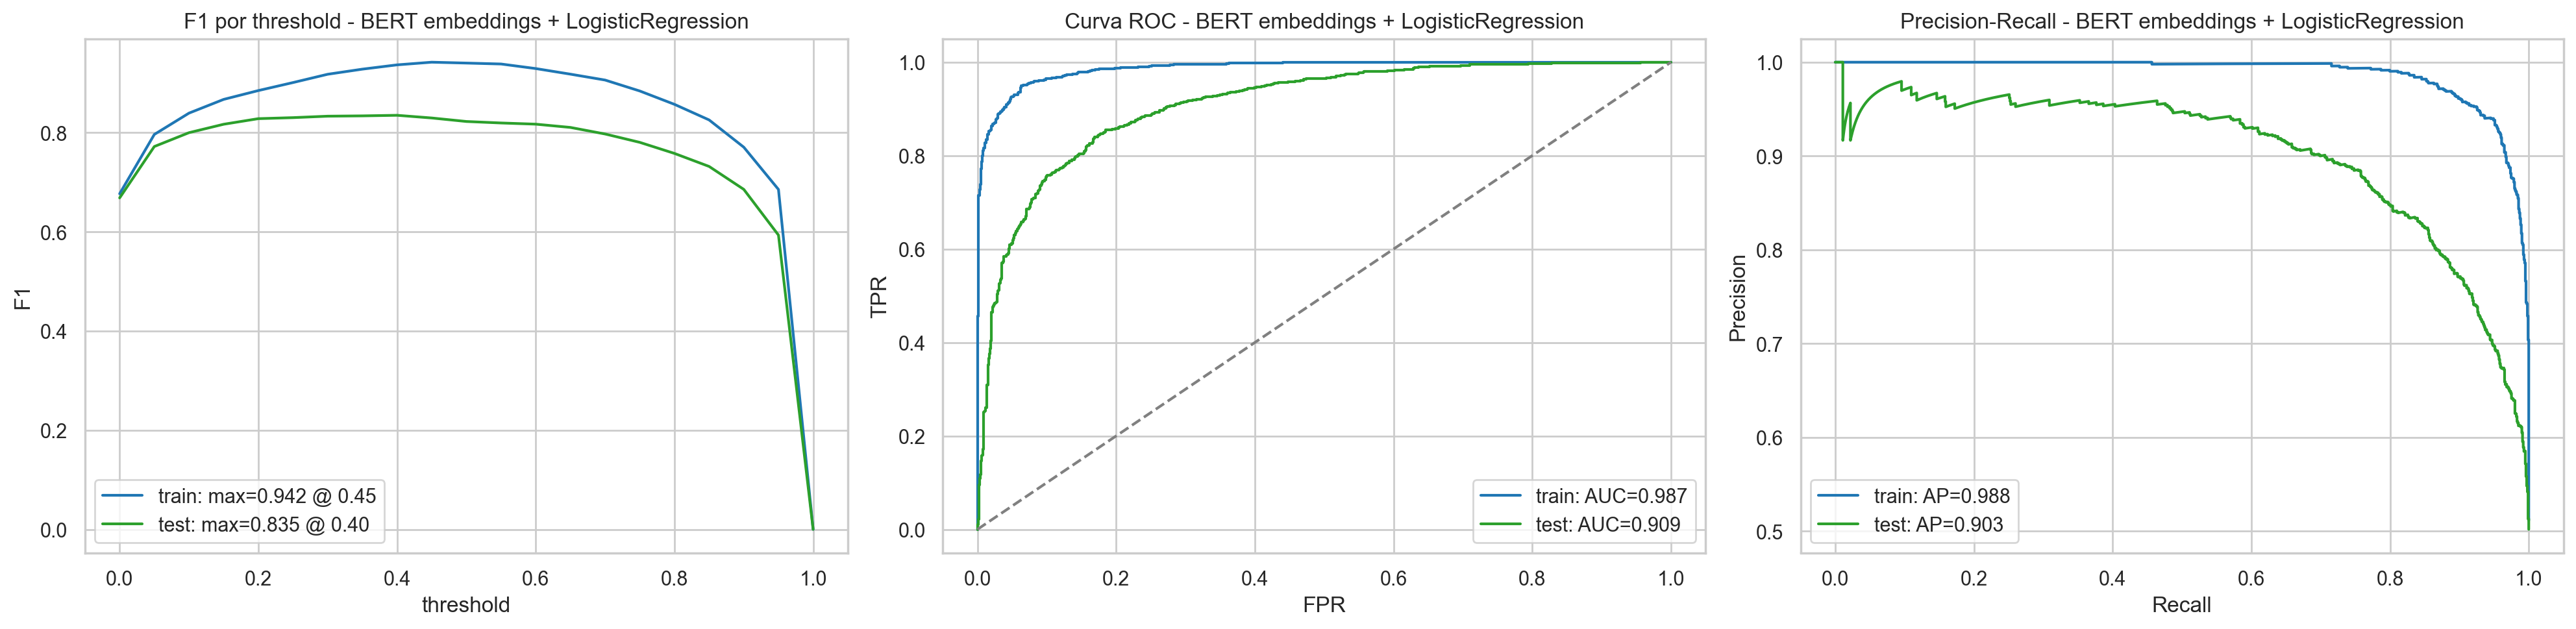

In [48]:
# Exemplo reduzido para nao deixar a execucao impraticavel em CPU.
sample_size = 2000
train_sample = df_reviews_train.sample(sample_size, random_state=42)
test_sample = df_reviews_test.sample(sample_size, random_state=42)

train_features_bert = BERT_text_to_embeddings(train_sample['review_norm'])
test_features_bert = BERT_text_to_embeddings(test_sample['review_norm'])

model_bert_lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model_bert_lr.fit(train_features_bert, train_sample['pos'])
evaluate_model(
    model_bert_lr,
    train_features_bert,
    train_sample['pos'],
    test_features_bert,
    test_sample['pos'],
    model_name='BERT embeddings + LogisticRegression'
)


## 13. Conclusoes

Preencha esta secao ao final da execucao:

- O conjunto parece balanceado ou nao?
- Qual modelo teve o melhor F1 no teste?
- A meta de `F1 >= 0.85` foi atingida?
- Houve sinais de overfitting?
- Como os modelos se comportaram nas reviews manuais?
- BERT trouxe ganho suficiente para justificar o custo computacional?
